In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/14986.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/3138.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/1700.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/16257.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/2863.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/771.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/12167.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/17643.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/6560.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/10162.jpg
/kaggl

# Mini-Project — The Model Lineup: Putting Pretrained CNNs to Work
## Task 1: Environment Setup and Data Loading¶

In [2]:
import torch
import torchvision
from torchvision import models, transforms
from torchvision.models import (
    ResNet18_Weights,
    MobileNet_V3_Small_Weights,
    EfficientNet_B0_Weights,
)
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import time
import random
import copy
import os
from pathlib import Path
from sklearn.decomposition import PCA

os.makedirs("outputs", exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

DATA_DIR = Path("/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test")
LABELS   = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

random.seed(42)


Using device: cuda


In [3]:
def load_images(n_per_class=10):
    """Load n images per class. Returns a list of (PIL.Image, label_string) tuples."""
    image_set = []
    for label in LABELS:
        class_dir = DATA_DIR / label
        paths = random.sample(list(class_dir.glob("*.jpg")), n_per_class)
        for path in paths:
            img = Image.open(path).convert("RGB")
            image_set.append((img, label))
    random.shuffle(image_set)
    return image_set

image_set = load_images(n_per_class=10)
print(f"Total images loaded: {len(image_set)}")

Total images loaded: 60


In [4]:
samples = []
for img, label in image_set:
    if label not in [s[1] for s in samples]:
        samples.append((img, label))
    if len(samples) == 6:
        break

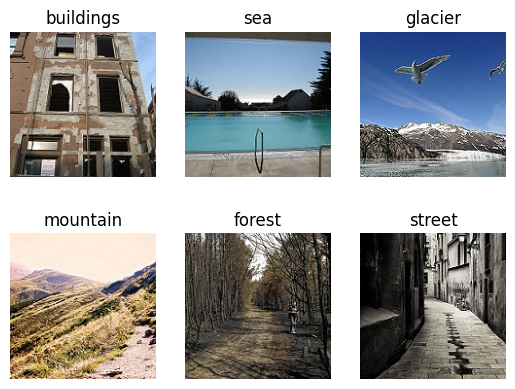

In [5]:
figure, axes = plt.subplots(2, 3)
        
for index, sample in enumerate(samples):
    img = sample[0]
    label = sample[1]
    axis = axes[index//3][index%3]
    axis.imshow(img)
    axis.set_title(label)
    axis.axis('off')
plt.savefig('dataset_sample.png', dpi=150, bbox_inches='tight')
plt.show()

Pretrained ImageNet model is a reasonable starting point - some classes overlap, and even with labels mismatch, image patterns like texture, shapes and edges are similar.

## Task 2: Baseline Inference with ResNet18

In [6]:
resnet_weights   = ResNet18_Weights.DEFAULT
resnet           = models.resnet18(weights=resnet_weights).to(device).eval()
resnet_preproc   = resnet_weights.transforms()
imagenet_classes = resnet_weights.meta["categories"]

print(f"ResNet18 parameters: {sum(p.numel() for p in resnet.parameters()):,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 139MB/s] 


ResNet18 parameters: 11,689,512


In [7]:
def run_inference(model, preprocess, image, device, labels, top_k=5):
    input_tensor = preprocess(image).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(input_tensor)
    probs = torch.nn.functional.softmax(output[0], dim=0)
    top = torch.topk(probs, top_k)
    return [(labels[top.indices[i].item()], top.values[i].item()) for i in range(top_k)]

In [8]:
resnet_results = []
for img, true_label in image_set:
    preds = run_inference(resnet, resnet_preproc, img, device, imagenet_classes)
    resnet_results.append({
        "true_label":   true_label,
        "top1_class":   preds[0][0],
        "top1_prob":    preds[0][1],
        "top5_classes": [p[0] for p in preds],
        "top5_probs":   [p[1] for p in preds],
    })

print(f"Processed {len(resnet_results)} images.")

Processed 60 images.


In [9]:
print(f"{'Overall mean:'} {np.mean([r['top1_prob'] for r in resnet_results]):.3f}")
prob_list = []
for label in LABELS:
    class_probs = [r['top1_prob'] for r in resnet_results if r['true_label'] == label]
    prob_list.append(class_probs)
    print(f"{label}: {np.mean(class_probs):.3f}")

Overall mean: 0.419
buildings: 0.289
forest: 0.248
glacier: 0.499
mountain: 0.556
sea: 0.571
street: 0.354


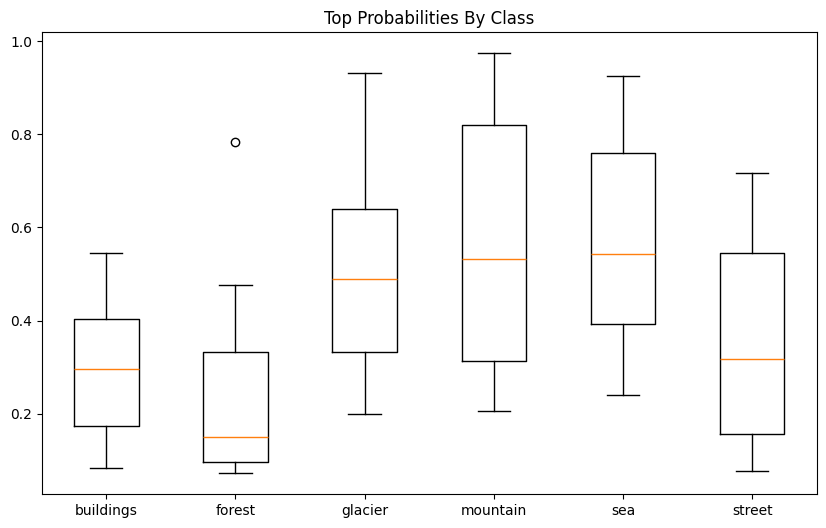

In [10]:
plt.figure(figsize=(10,6))
plt.boxplot(prob_list)
plt.xticks(range(1, 7), LABELS)
plt.title('Top Probabilities By Class')
plt.savefig("outputs/resnet18_confidence_by_class.png")
plt.show()

The boxplot shows the model has the highest confidence about sea, and the lowest about forest. in production, I would pay close attention to too high or too low confidence scores. Low score (under 20%) can point to a wrong choice; unreasonably high score (close to 100%) also needs a human reviewer to verify accuracy.

## Task 3: Multi-Model Comparison

In [11]:
# MobileNetV3-Small — designed for mobile and edge deployment
mobile_weights = MobileNet_V3_Small_Weights.DEFAULT
mobilenet      = models.mobilenet_v3_small(weights=mobile_weights).to(device).eval()
mobile_preproc = mobile_weights.transforms()

# EfficientNet-B0 — designed to maximize accuracy per unit of compute
effnet_weights = EfficientNet_B0_Weights.DEFAULT
efficientnet   = models.efficientnet_b0(weights=effnet_weights).to(device).eval()
effnet_preproc = effnet_weights.transforms()

# Print parameter counts for all three
for name, m in [("ResNet18",          resnet),
                ("MobileNetV3-Small", mobilenet),
                ("EfficientNet-B0",   efficientnet)]:
    params = sum(p.numel() for p in m.parameters())
    print(f"{name:22s}  {params:>12,} parameters")

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 70.6MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 102MB/s] 

ResNet18                  11,689,512 parameters
MobileNetV3-Small          2,542,856 parameters
EfficientNet-B0            5,288,548 parameters


Smaller number of parameters means less capacity, but more speed. Phone-optimized models should work faster but be less accurate.

In [12]:
mobilenet_results = []
for img, true_label in image_set:
    preds = run_inference(mobilenet, mobile_preproc, img, device, imagenet_classes)
    mobilenet_results.append({
        "true_label":   true_label,
        "top1_class":   preds[0][0],
        "top1_prob":    preds[0][1],
        "top5_classes": [p[0] for p in preds],
        "top5_probs":   [p[1] for p in preds],
    })

print(f"Processed {len(mobilenet_results)} images.")

Processed 60 images.


In [13]:
effnet_results = []
for img, true_label in image_set:
    preds = run_inference(efficientnet, effnet_preproc, img, device, imagenet_classes)
    effnet_results.append({
        "true_label":   true_label,
        "top1_class":   preds[0][0],
        "top1_prob":    preds[0][1],
        "top5_classes": [p[0] for p in preds],
        "top5_probs":   [p[1] for p in preds],
    })

print(f"Processed {len(effnet_results)} images.")

Processed 60 images.


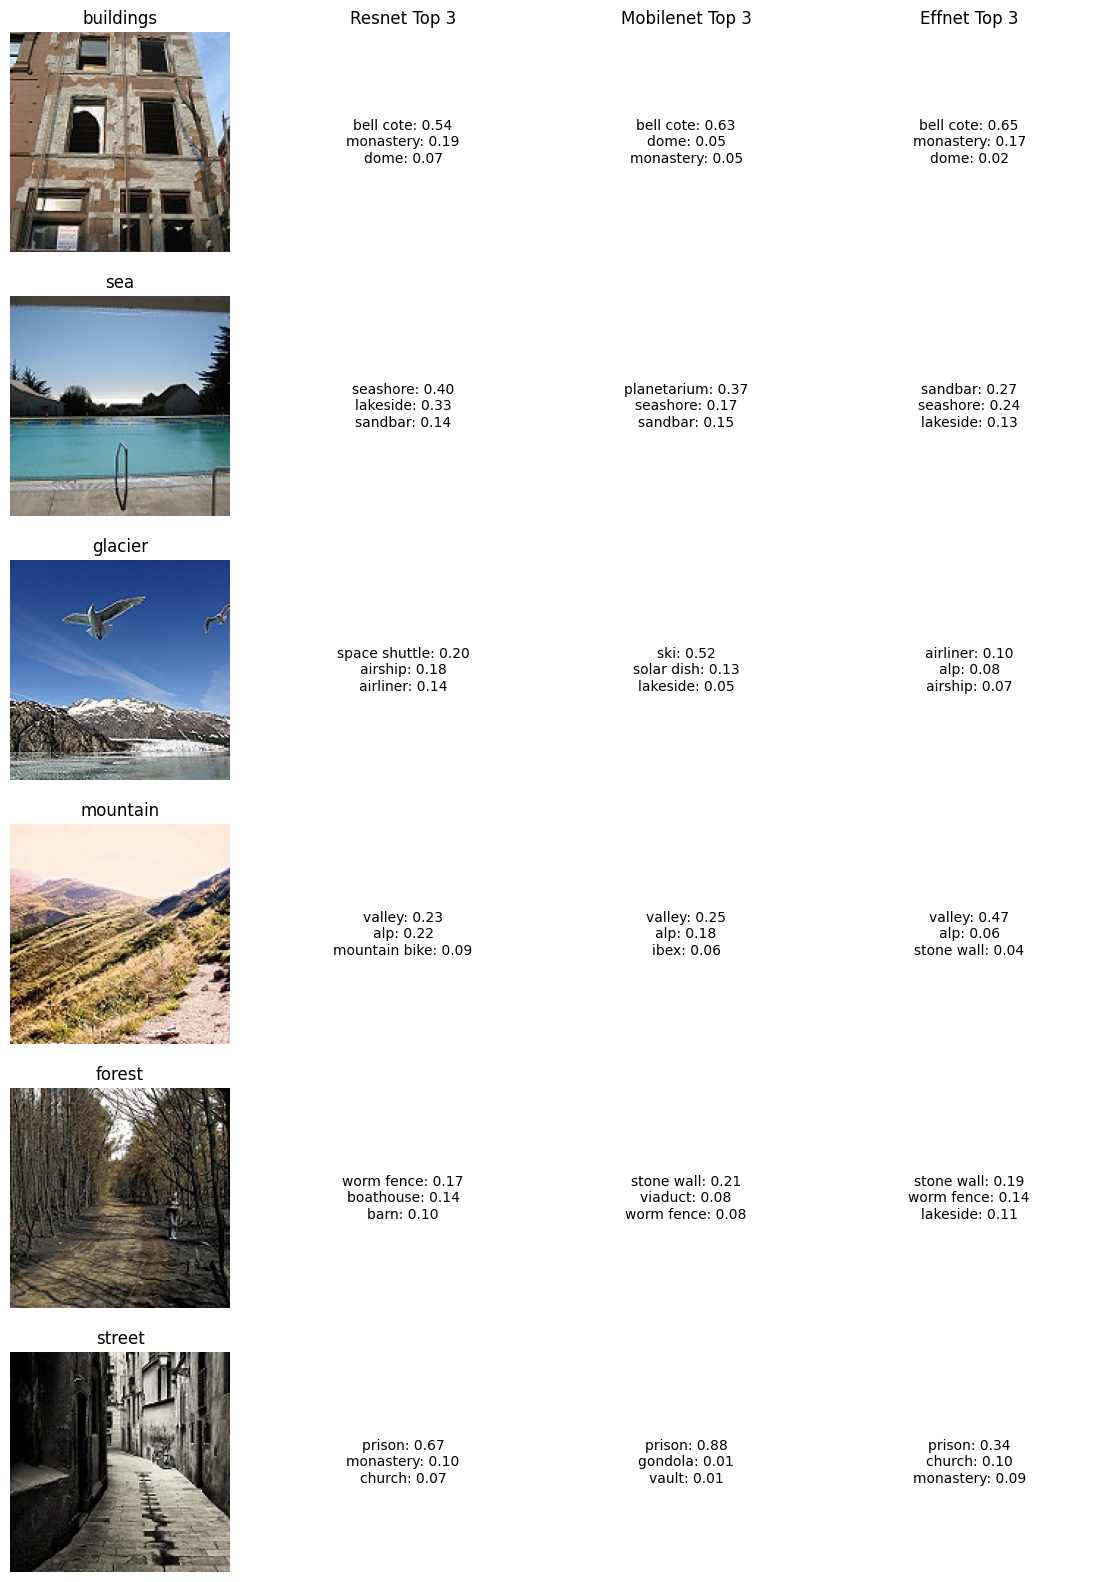

In [14]:
figure, axes = plt.subplots(6, 4, figsize=(14, 20))
for index, sample in enumerate(samples):
    img = sample[0]
    label = sample[1]
    axes[index][0].imshow(img)
    axes[index][0].set_title(label)
    axes[index][0].axis('off')
    if index == 0:
        axes[index][1].set_title('Resnet Top 3')
        axes[index][2].set_title('Mobilenet Top 3')
        axes[index][3].set_title('Effnet Top 3')
    resnet_preds  = run_inference(resnet, resnet_preproc, img, device, imagenet_classes, 3)
    mobile_preds  = run_inference(mobilenet, mobile_preproc, img, device, imagenet_classes, 3)
    effnet_preds  = run_inference(efficientnet, effnet_preproc, img, device, imagenet_classes, 3)
    all_preds = [resnet_preds, mobile_preds, effnet_preds]
    for i, model_preds in enumerate(all_preds):
        top3 = "\n".join([f"{name}: {prob:.2f}" for name, prob in model_preds])
        axes[index][i+1].text(0.5, 0.5, top3, 
    ha='center', va='center', transform=axes[index][i+1].transAxes)
        axes[index][i+1].axis('off')
plt.savefig("outputs/model_comparison_grid.png")

1. Three models generally agree on their top-1 prediction.
2. Unexpected picture (bird) made all three disagree. Combining predictions should increase accuracy.
3. Resnet model seems to be the most efficient.

## Task 4: Speed vs. Accuracy Tradeoff

In [15]:
def benchmark_model(model, preprocess, image_set, device, n_warmup=5):
    """
    Benchmark single-image inference speed.
    Returns mean latency in milliseconds per image.
    """
    # Warm up the GPU — the first few calls are slower due to CUDA initialization
    for img, _ in image_set[:n_warmup]:
        tensor = preprocess(img).unsqueeze(0).to(device)
        with torch.no_grad():
            _ = model(tensor)

    # Timed run — synchronize before and after to get accurate GPU timing
    torch.cuda.synchronize()
    start = time.time()

    for img, _ in image_set:
        tensor = preprocess(img).unsqueeze(0).to(device)
        with torch.no_grad():
            _ = model(tensor)

    torch.cuda.synchronize()
    elapsed = time.time() - start

    return (elapsed / len(image_set)) * 1000  # milliseconds per image

resnet_ms  = benchmark_model(resnet,       resnet_preproc,  image_set, device)
mobile_ms  = benchmark_model(mobilenet,    mobile_preproc,  image_set, device)
effnet_ms  = benchmark_model(efficientnet, effnet_preproc,  image_set, device)

print(f"ResNet18:           {resnet_ms:.2f} ms/image")
print(f"MobileNetV3-Small:  {mobile_ms:.2f} ms/image")
print(f"EfficientNet-B0:    {effnet_ms:.2f} ms/image")

ResNet18:           4.17 ms/image
MobileNetV3-Small:  7.53 ms/image
EfficientNet-B0:    10.42 ms/image


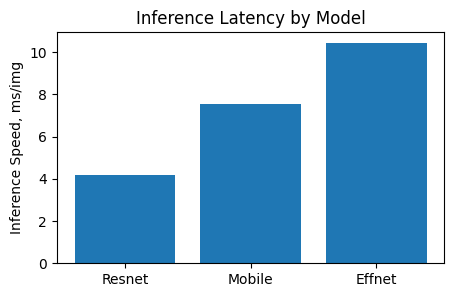

In [16]:
plt.figure(figsize=(5,3))
model_names = ['Resnet', 'Mobile', 'Effnet']
model_speed = [resnet_ms, mobile_ms, effnet_ms]
plt.bar(model_names, model_speed)
plt.title('Inference Latency by Model')
plt.ylabel('Inference Speed, ms/img')
plt.savefig("outputs/inference_speed.png")

| Model | Parameters | ms/image |
|-------|-----------|---------|
| ResNet18 | 11,689,512 | 4.01 |
| MobileNetV3-Small | 2,542,856 | 7.04 |
| EfficientNet-B0 | 5,288,548 | 10.13 |

 Maximum tolerable latency per image in milliseconds is 20, and all the models meet that bar.
  (a) a high-throughput cloud pipeline - Resnet - the fastest one
  (b) an on-device mobile app - Mobilenet - designed for mobile
  (c) a safety-critical quality-control system where getting it right matters more than speed - Effnet - most parameters, highest capacity.

## Task 5: Pretrained Features as a Window into Transfer Learning

In [17]:
import copy

feature_extractor = copy.deepcopy(resnet)
feature_extractor.fc = torch.nn.Identity()   # remove the classification head
feature_extractor    = feature_extractor.to(device).eval()

def extract_features(model, preprocess, image, device):
    """Extract a feature vector from an image using the truncated CNN."""
    tensor   = preprocess(image).unsqueeze(0).to(device)
    with torch.no_grad():
        features = model(tensor)
    return features.squeeze().cpu().numpy()

# Extract features for all images
feature_vectors = []
true_labels     = []

for img, label in image_set:
    feat = extract_features(feature_extractor, resnet_preproc, img, device)
    feature_vectors.append(feat)
    true_labels.append(label)

feature_matrix = np.array(feature_vectors)
print(f"Feature matrix shape: {feature_matrix.shape}")
# Expected: (60, 512) — 60 images, 512-dimensional feature vector each

Feature matrix shape: (60, 512)


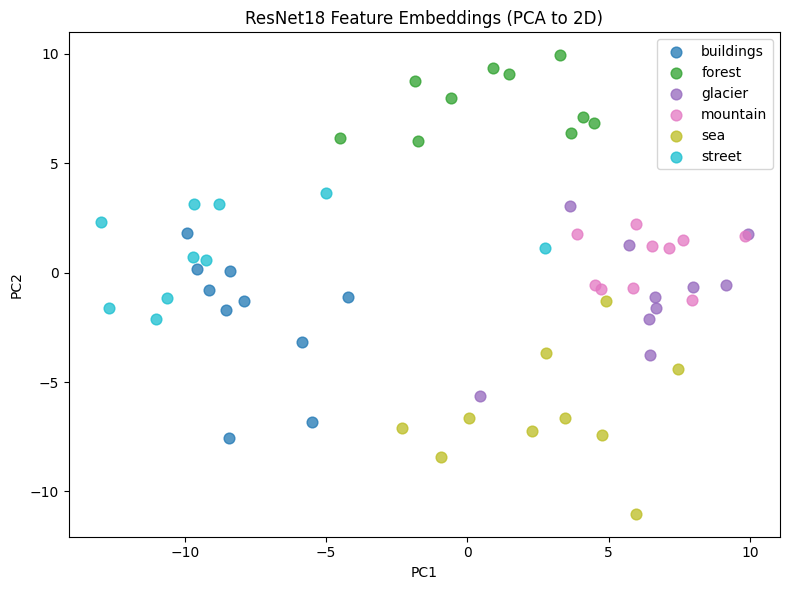

In [18]:
pca          = PCA(n_components=2)
features_2d  = pca.fit_transform(feature_matrix)

fig, ax = plt.subplots(figsize=(8, 6))
colors  = plt.cm.tab10(np.linspace(0, 1, len(LABELS)))

for i, label in enumerate(LABELS):
    mask = [l == label for l in true_labels]
    ax.scatter(
        features_2d[mask, 0],
        features_2d[mask, 1],
        label=label, color=colors[i], s=60, alpha=0.75
    )

ax.legend()
ax.set_title("ResNet18 Feature Embeddings (PCA to 2D)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.tight_layout()
plt.savefig("outputs/feature_embeddings.png")
plt.show()

1. The images of the same class do cluster together. The model has already learned visual features - shapes, edges - after being trained on ImageNet and before seeing the task specific data.
2. On a sample of 500 it's more reliable to use the feature extraction. Fine tuning on a small sample may cause overfitting.

## Task 6: Summary and Recommendation

### Model Comparison:

ResNet model performed best overall on the data set we used. It showed the best speed: 4.04 ms/image, had the most accurate prediction and high confidence.

### Confidence Calibration: 

It showed higher confidence score for sea and mountain images, and lowest confidence for forest since those images have more variety.

### Production Recommendation:

I'd suggest starting with ResNet because of high speed and accuracy. 
Preprocessing steps: crop and resize, use ToTensor() to transform pixel values to 0-1 range, normalize using mean and std values.
Potential risk: low quality or heavily modified photos that are very different from the trained set and may be missclassified.